# Figure regeneration notebook

This notebook reproduces every figure used in the paper from the data
under `data/`. Each cell is **self-contained**: load → plot → save PNG+PDF.
Outputs go to `output/`.

| # | name | data |
|---|------|------|
| 01 | cliff_boundary | (none, computed) |
| 02 | cliff_rate (% traces with ≥1 cliff) | `02_threshold_comparison_pct/rates.json` |
| 03 | cliff_count (avg cliffs per trace) | `03_threshold_comparison_avg/rates.json` |
| 04 | passk (model × dataset grid) | `04_pass_at_k_grid/pass_at_k.csv` |
| 05–10 | pmass_<model> (sum P(cliff) boxplot) | `0X_exp2_2_<model>/boxplot_points.csv` |
| 06 | recovery_qwen8b (Type3 greedy recovery) | `05_06_exp2_2_Qwen3-8B/type3_recovery_points.csv` |
| 11 | dcpm_violin (Δ CPM by taxonomy × direction) | `11_14_exp2_3_extra_plots/{small,big}*per_cliff.csv` |
| 12–14 | rank_{DC,UC,SC} (rank-shift heatmap) | `11_14_exp2_3_extra_plots/{small,big}*per_token.csv` (+ selected-cliff keys) |
| 15 | entropy_density (5-panel KDE) | `15_entropy_density/entropy_arrays.npz` |
| 16 | passk_incorrect (incorrect-trace pass@k, transposed) | `16_pass_at_k_failure_only/pass_at_k_failure_only.csv` |

Run all cells: each figure's PNG and PDF appear in `output/`.


In [1]:
import csv, json, math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

DATA = Path("data")
OUT = Path("output"); OUT.mkdir(exist_ok=True)

def save_fig(fig, name, dpi=170):
    fig.savefig(OUT / f"{name}.png", dpi=dpi, bbox_inches="tight")
    fig.savefig(OUT / f"{name}.pdf", format="pdf", bbox_inches="tight")
    print(f"saved {name}.png + .pdf")

# Shared style constants (lifted from src/analysis/curves.py & evaluator.py)
SUCCESS_COLOR = "#90CAF9"
FAILURE_COLOR = "#EF9A9A"

def apply_style():
    plt.rcParams.update({
        "figure.dpi": 150, "font.size": 14,
        "axes.titlesize": 16, "axes.labelsize": 15, "legend.fontsize": 13,
        "xtick.labelsize": 13, "ytick.labelsize": 13,
    })
    sns.set_style("whitegrid")

# Display name normalization: capitalize first letter and strip
# trailing -Instruct / -it suffixes from model names.
MODEL_DISPLAY = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B",
    "Llama-3.2-3B-Instruct": "Llama-3.2-3B",
    "Llama-3.2-1B-Instruct": "Llama-3.2-1B",
    "gemma-3-4b-it":         "Gemma-3-4B",
}
def display_model(m):
    return MODEL_DISPLAY.get(m, m)


saved fig01_cliff_boundary.png + .pdf


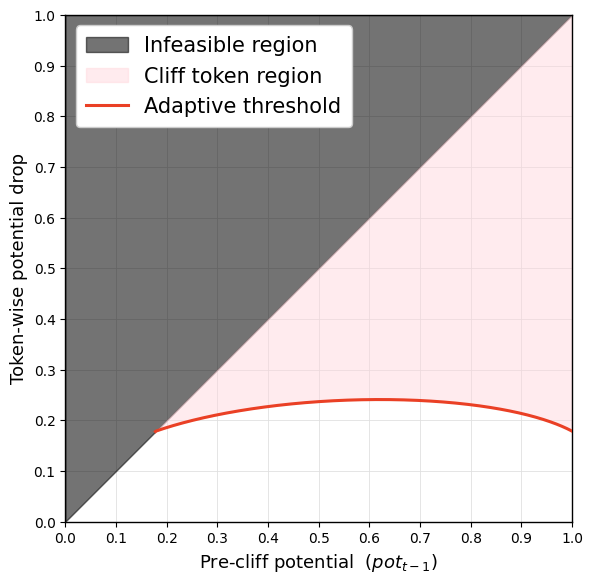

In [2]:
# ─── Figure 01: statistical cliff boundary (no input data) ───
# Reproduces the statistical cliff boundary from local constants
# Lifted from scripts/exp1_1_plot_cliff_boundary.py. Constants from
# src/analysis/cliff_threshold.py:
#   DEFAULT_N=64, DEFAULT_DELTA_0=0.1, DEFAULT_Z_ALPHA=1.645
N, delta_0, z_alpha = 64, 0.1, 1.645

def min_drop_continuous(p_prev):
    """For a given p_prev, find the minimum drop that triggers cliff."""
    if p_prev <= 0:
        return None
    lo, hi = delta_0, p_prev
    if lo >= hi:
        return None
    for _ in range(100):
        mid = (lo + hi) / 2
        p_curr = max(p_prev - mid, 0)
        var = p_prev * (1 - p_prev) / N + p_curr * (1 - p_curr) / N
        se = math.sqrt(var) if var > 0 else 0
        threshold = delta_0 + z_alpha * se
        if mid > threshold:
            hi = mid
        else:
            lo = mid
    return (lo + hi) / 2

x_pts, y_pts = [], []
for p in np.linspace(0.001, 1.0, 1000):
    d = min_drop_continuous(p)
    if d is not None and d < p - 1e-6:
        x_pts.append(p); y_pts.append(d)
x_boundary, y_boundary = np.array(x_pts), np.array(y_pts)
# prepend the point where boundary meets the diagonal so the line starts
# cleanly from the diagonal
if len(x_boundary) > 0:
    x0 = x_boundary[0]
    x_boundary = np.concatenate([[x0 - 0.001], x_boundary])
    y_boundary = np.concatenate([[x0 - 0.001], y_boundary])

YMAX = 1.0
# plt.rcParams.update({"figure.dpi": 150, "font.size": 11, "font.family": "Aptos"})
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(True, color="#e0e0e0", linewidth=0.6); ax.set_axisbelow(True)

# Set x/y axis spines to 1pt
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

diag_x = np.linspace(0, 1.0, 500)
ax.fill_between(diag_x, diag_x, YMAX, color="#000000", alpha=0.55,
                label="Infeasible region")
upper = np.minimum(x_boundary, YMAX)
ax.fill_between(x_boundary, y_boundary, upper, color="#FFD4DB", alpha=0.45,  #"#FFD4DB"
                label="Cliff token region", zorder=2)
ax.plot(x_boundary, y_boundary, color="#EA4025", linewidth=2.2,
        label="Adaptive threshold", zorder=3) #"#EA4025"

ax.set_xlabel(r"Pre-cliff potential  ($pot_{t-1}$)", fontsize=13)
ax.set_ylabel("Token-wise potential drop", fontsize=13)
ax.set_xlim(0, 1.0); ax.set_ylim(0, YMAX)
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=15, framealpha=1, borderpad=0.5)
fig.tight_layout()
save_fig(fig, "fig01_cliff_boundary")
plt.show()
plt.close(fig)

saved fig02_03_cliff_stats_combined.png + .pdf


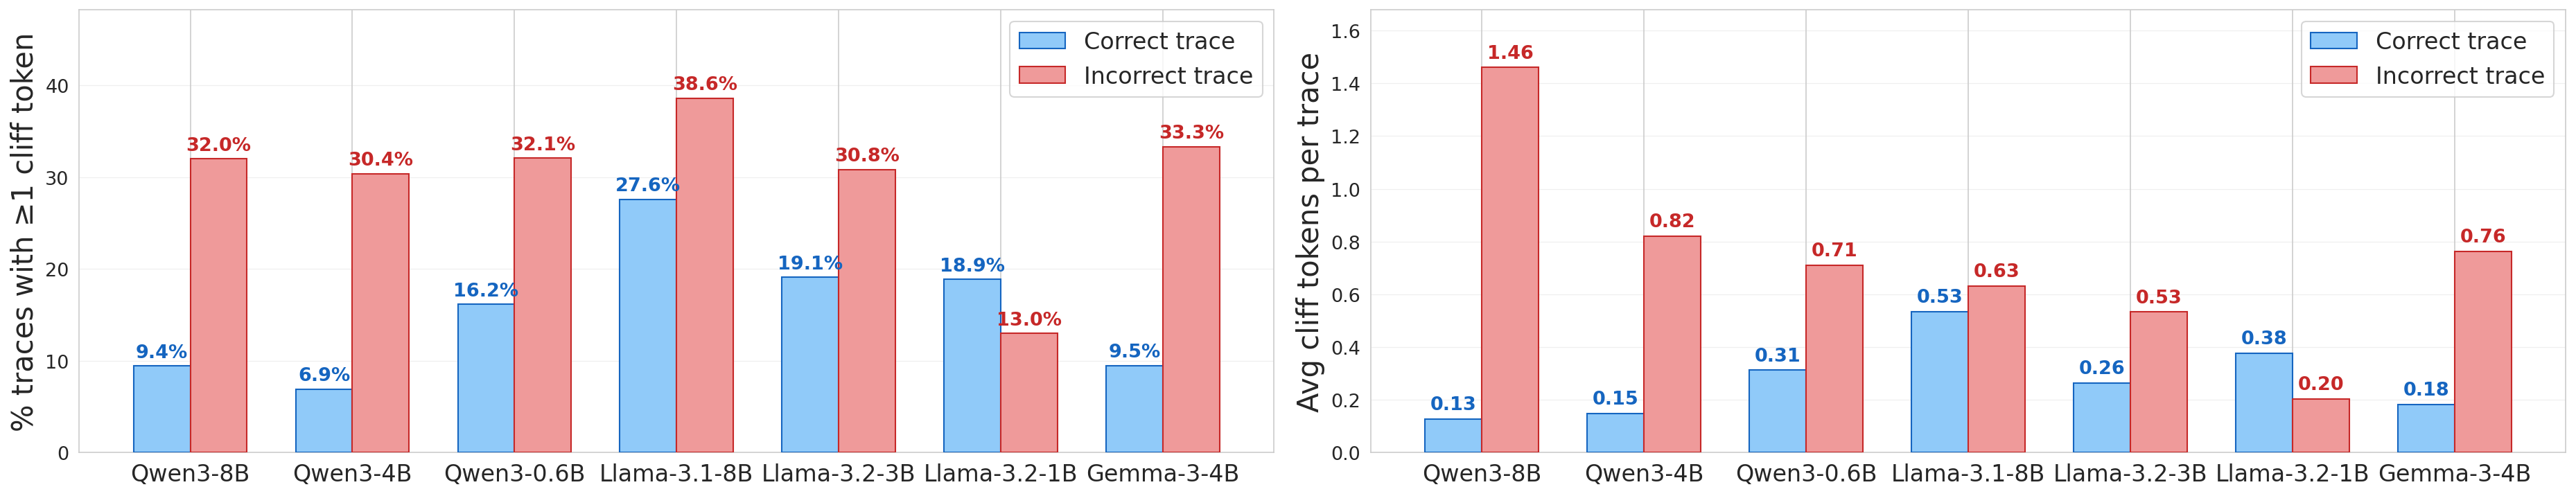

In [12]:
# ─── Figure 02+03 combined: prevalence (%) + intensity (avg) side by side ───
rates_pct = json.loads((DATA / "02_threshold_comparison_pct/rates.json").read_text())
rates_avg = json.loads((DATA / "03_threshold_comparison_avg/rates.json").read_text())

FS = {"tick": 16, "label": 20, "legend": 16, "annot": 13, "subplot": 22}
apply_style()
models = list(rates_avg.keys())
n_models = len(models)
x = np.arange(n_models)
bar_w = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 5))

# ── Left: cliff prevalence (% traces with ≥1 cliff) ──
s_pct = [rates_pct[m]["success"] for m in models]
f_pct = [rates_pct[m]["failure"] for m in models]

bars_s1 = ax1.bar(x - bar_w/2, s_pct, bar_w, color=SUCCESS_COLOR, edgecolor="#1565C0",
                  linewidth=1.0, label="Correct trace", zorder=3)
bars_f1 = ax1.bar(x + bar_w/2, f_pct, bar_w, color=FAILURE_COLOR, edgecolor="#C62828",
                  linewidth=1.0, label="Incorrect trace", zorder=3)

for bar in bars_s1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}%", ha="center", va="bottom",
             fontsize=FS["annot"], color="#1565C0", fontweight="bold")
for bar in bars_f1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}%", ha="center", va="bottom",
             fontsize=FS["annot"], color="#C62828", fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels([display_model(m) for m in models], fontsize=FS["tick"])
ax1.set_ylabel("% traces with ≥1 cliff token", fontsize=FS["label"])
ax1.set_ylim(0, max(f_pct) * 1.25)
ax1.grid(True, axis="y", alpha=0.3, linewidth=0.6)
ax1.legend(fontsize=FS["legend"], loc="upper right")

# ── Right: avg cliff tokens per trace ──
s_avg = [rates_avg[m]["success"] for m in models]
f_avg = [rates_avg[m]["failure"] for m in models]

bars_s2 = ax2.bar(x - bar_w/2, s_avg, bar_w, color=SUCCESS_COLOR, edgecolor="#1565C0",
                  linewidth=1.0, label="Correct trace", zorder=3)
bars_f2 = ax2.bar(x + bar_w/2, f_avg, bar_w, color=FAILURE_COLOR, edgecolor="#C62828",
                  linewidth=1.0, label="Incorrect trace", zorder=3)

for bar in bars_s2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{bar.get_height():.2f}", ha="center", va="bottom",
             fontsize=FS["annot"], color="#1565C0", fontweight="bold")
for bar in bars_f2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{bar.get_height():.2f}", ha="center", va="bottom",
             fontsize=FS["annot"], color="#C62828", fontweight="bold")

ax2.set_xticks(x)
ax2.set_xticklabels([display_model(m) for m in models], fontsize=FS["tick"])
ax2.set_ylabel("Avg cliff tokens per trace", fontsize=FS["label"])
ax2.set_ylim(0, max(f_avg) * 1.15)
ax2.grid(True, axis="y", alpha=0.3, linewidth=0.6)
ax2.legend(fontsize=FS["legend"], loc="upper right")

fig.tight_layout()
save_fig(fig, "fig02_03_cliff_stats_combined")
plt.show()
plt.close(fig)

In [4]:
# ─── Figure 05 family: exp2_2 sum_p_cliff boxplots (single-model) ───
# Adapted from src/analysis/exp2_2_aggregator.py:_build_taxonomy_boxplot.
# Each model gets its own figure (boxplot per taxonomy on x-axis, just one model).
import pandas as pd

FS = {"tick": 22, "label": 22, "legend": 22, "annot": 18}
TYPE_ORDER = [("type1", "Deterministic",  "DF"),
              ("type2", "Uncertain",      "AG"),
              ("type3", "Sampled-off",    "SS")]

EXP2_2_FIG_BY_MODEL = [
    ("Qwen3-8B",             "05_06_exp2_2_Qwen3-8B",             "fig05_pmass_qwen3_8b"),
    ("Qwen3-4B",             "07_exp2_2_Qwen3-4B",                "fig05_pmass_qwen3_4b"),
    ("Qwen3-0.6B",           "08_exp2_2_Qwen3-0.6B",              "fig05_pmass_qwen3_06b"),
    ("Llama-3.1-8B-Instruct", "09_exp2_2_Llama-3.1-8B-Instruct",  "fig05_pmass_llama31_8b"),
    ("Llama-3.2-3B-Instruct", "19_exp2_2_Llama-3.2-3B-Instruct",  "fig05_pmass_llama32_3b"),
    ("Llama-3.2-1B-Instruct", "20_exp2_2_Llama-3.2-1B-Instruct",  "fig05_pmass_llama32_1b"),
    ("gemma-3-4b-it",        "10_exp2_2_gemma-3-4b-it",           "fig05_pmass_gemma4b"),
]

def boxplot_sum_p_cliff(model_name, csv_dir, out_name):
    apply_style()
    df = pd.read_csv(DATA / csv_dir / "boxplot_points.csv")
    fig, ax = plt.subplots(figsize=(7.6, 6.0))
    color = "#ef9a9a"

    type_keys = [t[2] for t in TYPE_ORDER]
    xticks = list(range(len(type_keys)))
    xtick_labels = [t[1] for t in TYPE_ORDER]
    for ti, tk in enumerate(type_keys):
        vals = df[df["taxonomy_type"] == tk]["sum_p_cliff"].tolist()
        if not vals: continue
        ax.boxplot([vals], positions=[ti], widths=0.6,
                   patch_artist=True, showmeans=True,
                   meanprops={"marker": "D", "markerfacecolor": "white",
                              "markeredgecolor": "black", "markersize": 10},
                   medianprops={"color": "black", "linewidth": 3},
                   boxprops={"facecolor": color, "alpha": 0.75,
                             "edgecolor": "black", "linewidth": 1},
                   whiskerprops={"color": "black", "linewidth": 1},
                   capprops={"color": "black", "linewidth": 1},
                   flierprops={"marker": "o", "markerfacecolor": color,
                               "markeredgecolor": "black", "markersize": 3,
                               "alpha": 0.6})
        median_v = float(np.median(vals))
        ax.text(ti + 0.35, median_v, f"{median_v:.3f}", ha="left", va="center",
                fontsize=FS["annot"], color="black")

    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel("Cliff probability mass", fontsize=FS["label"])
    ax.grid(True, axis="y", alpha=0.3, linewidth=0.6)
    # Move x-axis labels to top
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, fontsize=FS["tick"])
    fig.tight_layout()
    save_fig(fig, out_name)
    plt.close(fig)

for model, csv_dir, out_name in EXP2_2_FIG_BY_MODEL:
    boxplot_sum_p_cliff(model, csv_dir, out_name)

saved fig05_pmass_qwen3_8b.png + .pdf
saved fig05_pmass_qwen3_4b.png + .pdf
saved fig05_pmass_qwen3_06b.png + .pdf
saved fig05_pmass_llama31_8b.png + .pdf
saved fig05_pmass_llama32_3b.png + .pdf
saved fig05_pmass_llama32_1b.png + .pdf
saved fig05_pmass_gemma4b.png + .pdf


In [5]:
# ─── Figure 06: exp2_2 type3 greedy recovery scatter (Qwen3-8B) ───
# Adapted from src/analysis/exp2_2_aggregator.py:_build_type3_recovery.
import pandas as pd
df = pd.read_csv(DATA / "05_06_exp2_2_Qwen3-8B/type3_recovery_points.csv")

FS = {"label": 15}
apply_style()
fig, ax = plt.subplots(figsize=(7, 6))
if not df.empty:
    ax.scatter(df["selected_potential"], df["greedy_potential"],
               color="#000000", s=30, alpha=0.75, linewidths=0)
else:
    ax.text(0.5, 0.5, "No Type3 points available", ha="center", va="center",
            transform=ax.transAxes)
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.0, color="gray")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Cliff token potential", fontsize=FS["label"])
ax.set_ylabel("Greedy token potential", fontsize=FS["label"])
ax.grid(True, alpha=0.25, linewidth=0.6)
fig.tight_layout()
save_fig(fig, "fig06_recovery_qwen3_8b")
plt.close(fig)

saved fig06_recovery_qwen3_8b.png + .pdf


saved fig11_dcpm_violin_qwen3.png + .pdf


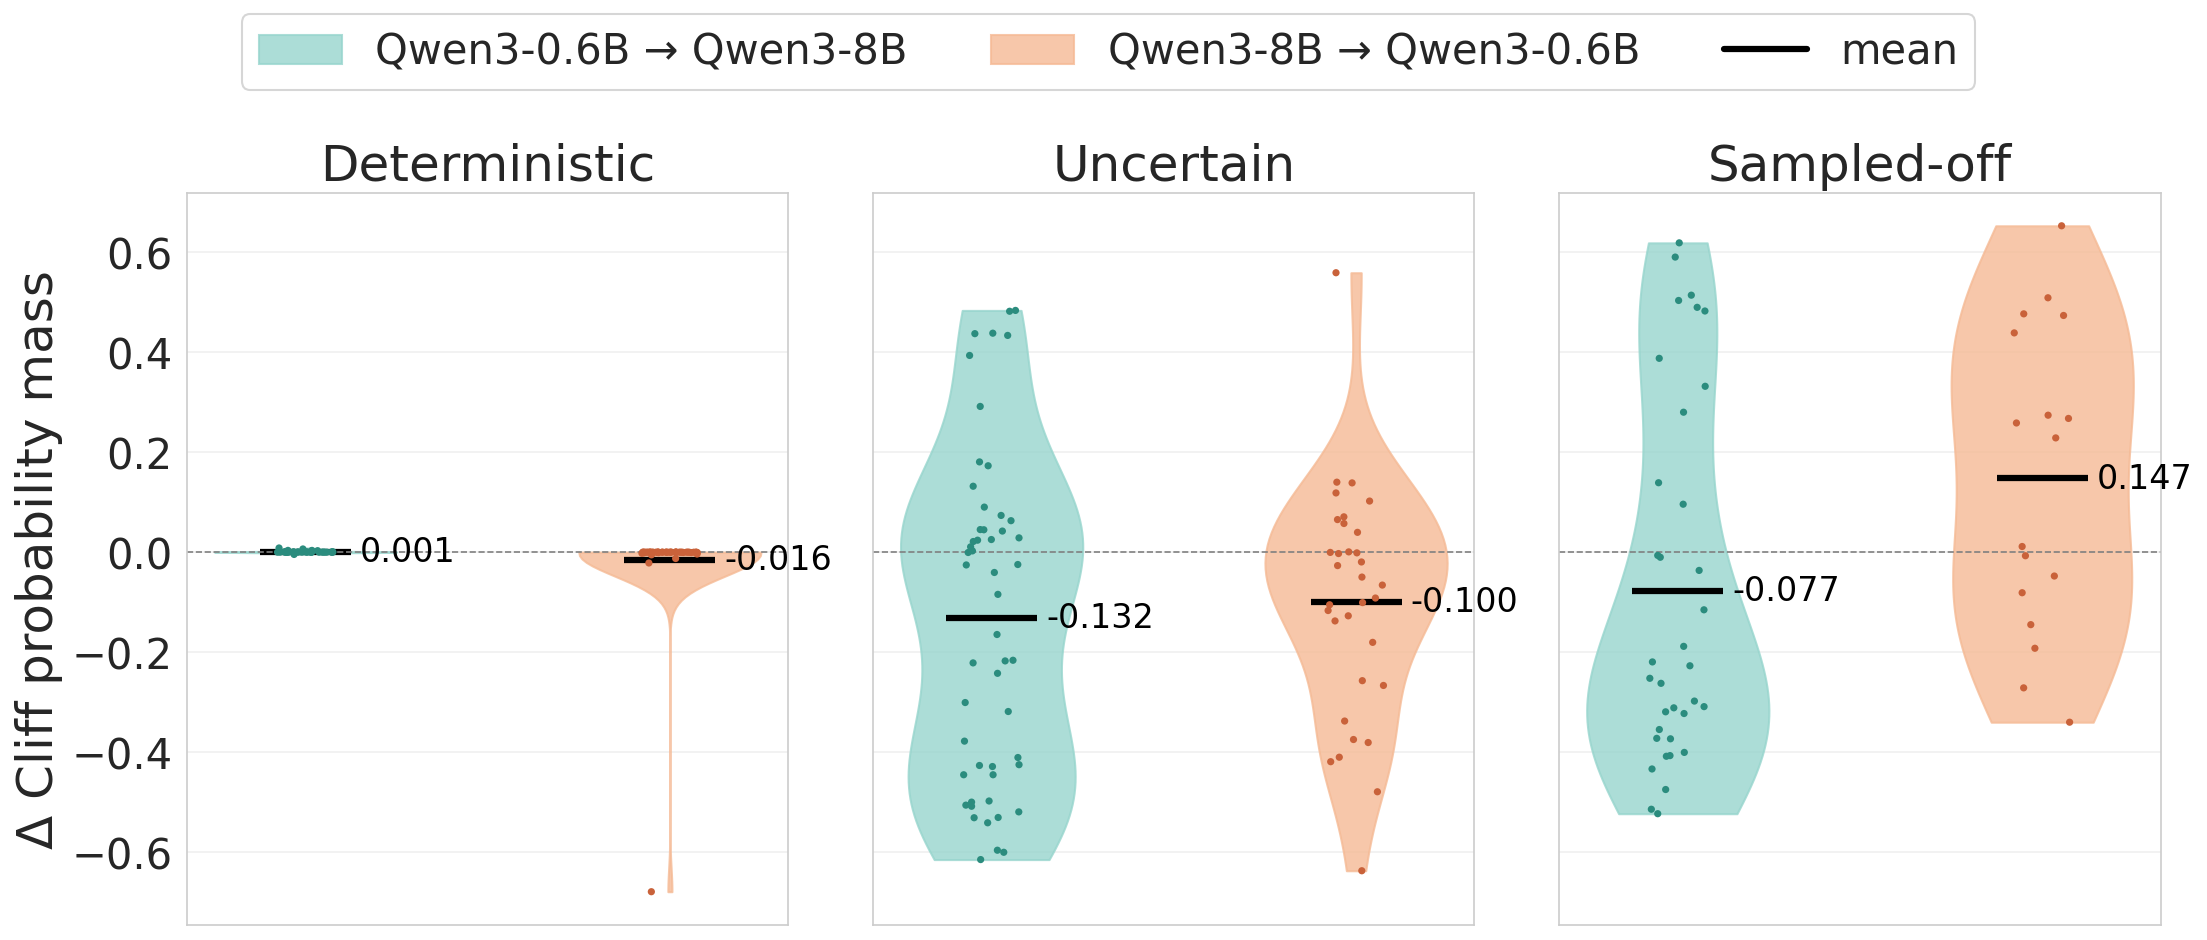

saved fig11_dcpm_violin_llama.png + .pdf


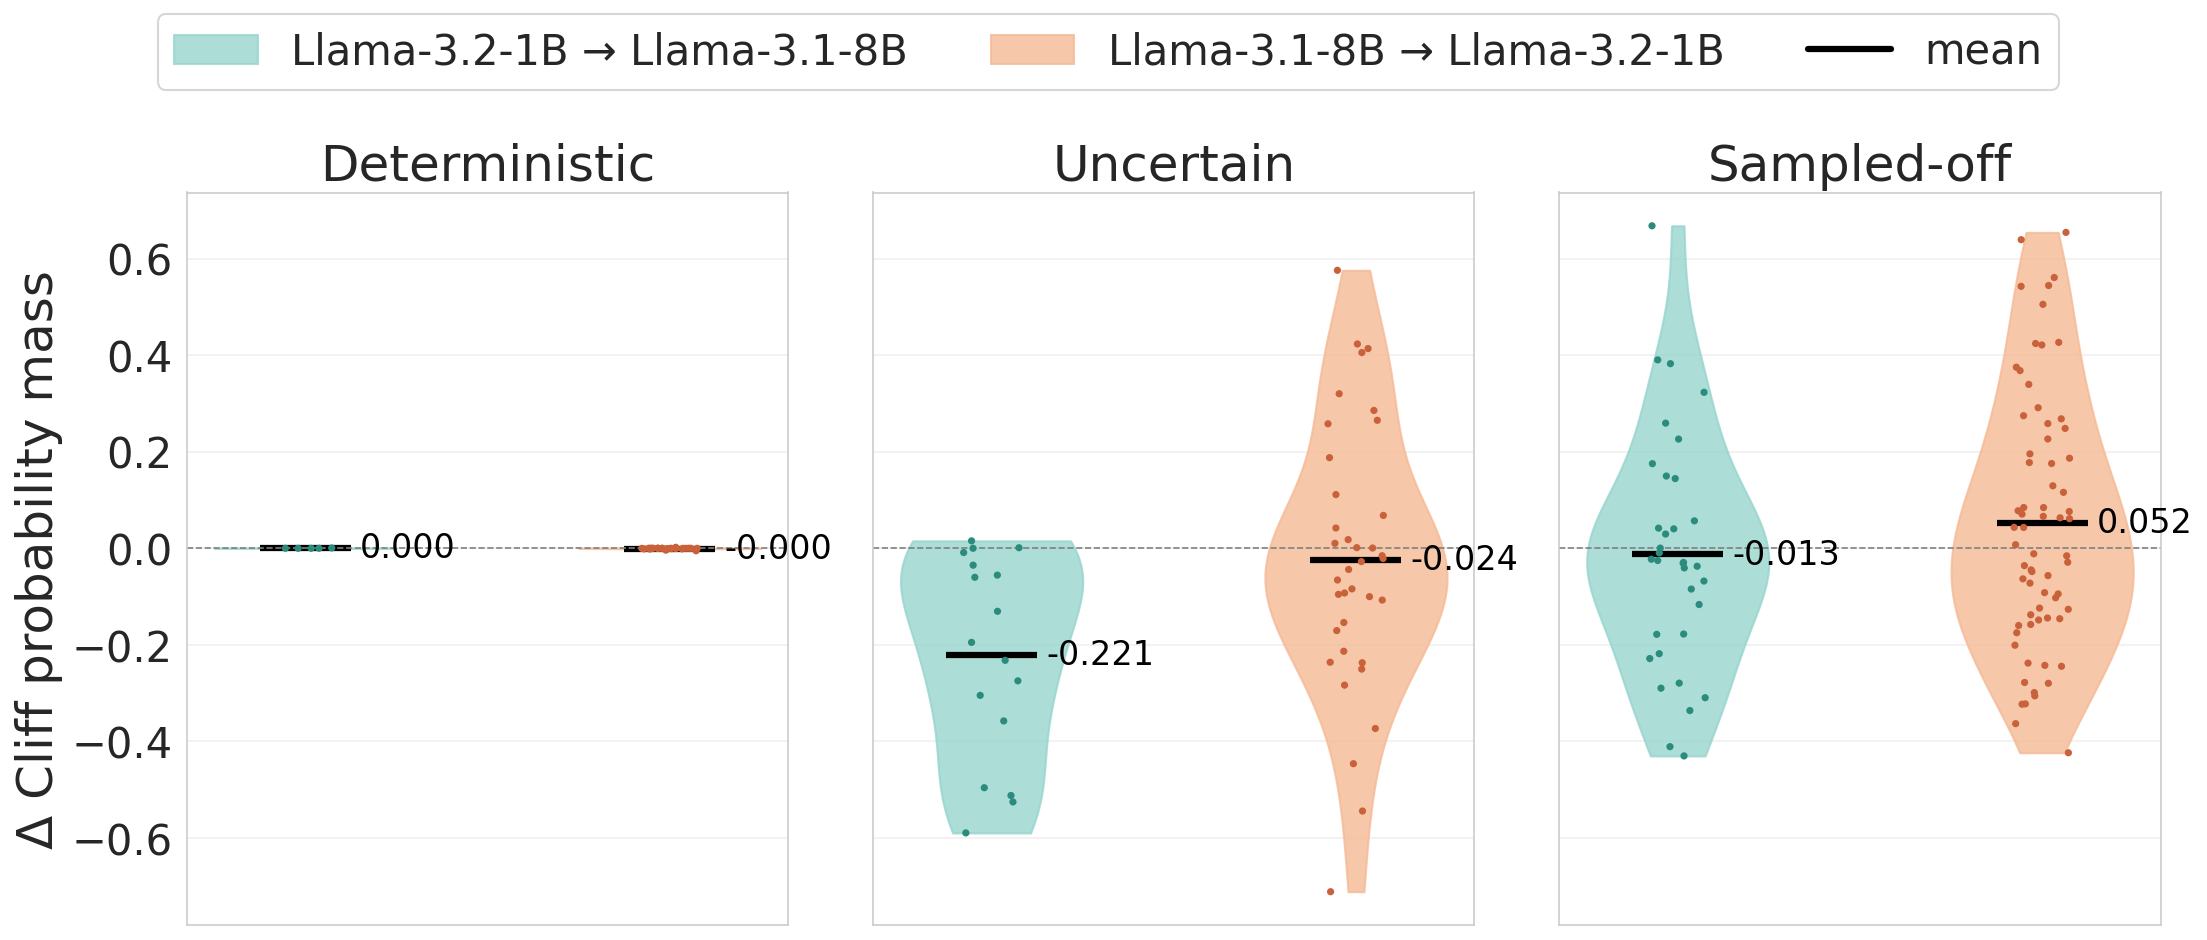

In [14]:
# ─── Figure 11 family: exp2_3 delta CPM violin (Qwen3 and Llama) ───
# Lifted from scripts/exp2_3_extra_plots.py:plot1_delta_cpm_violin.
import pandas as pd
FS = {"title": 24, "label": 24, "legend": 20, "ytick": 20, "annot": 16}
TAXONOMY_ORDER = ["DF", "AG", "SS"]
TAXONOMY_LABELS = {"DF": "Deterministic",
                   "AG": "Uncertain",
                   "SS": "Sampled-off"}

COLOR_STB       = "#97d5cd"
COLOR_BTS       = "#f5ba95"
COLOR_STB_DOT   = "#2b8c7e"
COLOR_BTS_DOT   = "#c9623a"

EXP2_3_FAMILIES = [
    ("qwen3", DATA / "11_14_exp2_3_qwen3_extra_plots",
     "Qwen3-0.6B → Qwen3-8B", "Qwen3-8B → Qwen3-0.6B"),
    ("llama", DATA / "11_14_exp2_3_llama_extra_plots",
     "Llama-3.2-1B → Llama-3.1-8B", "Llama-3.1-8B → Llama-3.2-1B"),
]

def plot_dcpm_violin(family_suffix, base, label_stb, label_bts):
    data = {
        "smalltobig": {"cliff": pd.read_csv(base / "smalltobig_per_cliff.csv").to_dict("records")},
        "bigtosmall": {"cliff": pd.read_csv(base / "bigtosmall_per_cliff.csv").to_dict("records")},
    }

    apply_style()
    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
    for ti, tax in enumerate(TAXONOMY_ORDER):
        ax = axes[ti]
        parts_data = []
        for direction in ["smalltobig", "bigtosmall"]:
            vals = [r["delta_cpm"] for r in data[direction]["cliff"]
                    if r["taxonomy_type"] == tax]
            parts_data.append(vals)
        if all(len(d) > 0 for d in parts_data):
            vp = ax.violinplot(parts_data, positions=[0, 1],
                               showmeans=True, showmedians=False, showextrema=False)
            for body, color in zip(vp["bodies"], [COLOR_STB, COLOR_BTS]):
                body.set_facecolor(color)
                body.set_alpha(0.8)
                body.set_edgecolor(color)
            vp["cmeans"].set_color("black")
            vp["cmeans"].set_linewidth(3)
            for i, (vals, dot_color) in enumerate(zip(parts_data, [COLOR_STB_DOT, COLOR_BTS_DOT])):
                jitter = np.random.RandomState(42).uniform(-0.08, 0.08, len(vals))
                ax.scatter(np.full(len(vals), i) + jitter, vals, s=12, alpha=1.0,
                           c=dot_color, edgecolors="none", zorder=3)
                mean_v = float(np.mean(vals))
                ax.text(i + 0.15, mean_v, f"{mean_v:.3f}", ha="left", va="center",
                        fontsize=FS["annot"], color="black", zorder=4)
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        ax.set_xticks([])
        ax.set_title(TAXONOMY_LABELS[tax], fontsize=FS["title"])
        ax.grid(True, alpha=0.3, axis="y")
        ax.tick_params(axis="y", labelsize=FS["ytick"])
    axes[0].set_ylabel("Δ Cliff probability mass", fontsize=FS["label"])

    handles = [Patch(facecolor=COLOR_STB, alpha=0.8, edgecolor=COLOR_STB, label=label_stb),
               Patch(facecolor=COLOR_BTS, alpha=0.8, edgecolor=COLOR_BTS, label=label_bts),
               Line2D([0], [0], color="black", linewidth=3, label="mean")]
    fig.legend(handles=handles, loc="lower center", ncol=3,
               bbox_to_anchor=(0.5, 1.0), frameon=True, fontsize=FS["legend"])
    fig.tight_layout(rect=[0, 0.06, 1, 1])
    save_fig(fig, f"fig11_dcpm_violin_{family_suffix}")
    plt.show()
    plt.close(fig)

for family_suffix, base, label_stb, label_bts in EXP2_3_FAMILIES:
    plot_dcpm_violin(family_suffix, base, label_stb, label_bts)


saved fig12_rank_DC_qwen3.png + .pdf


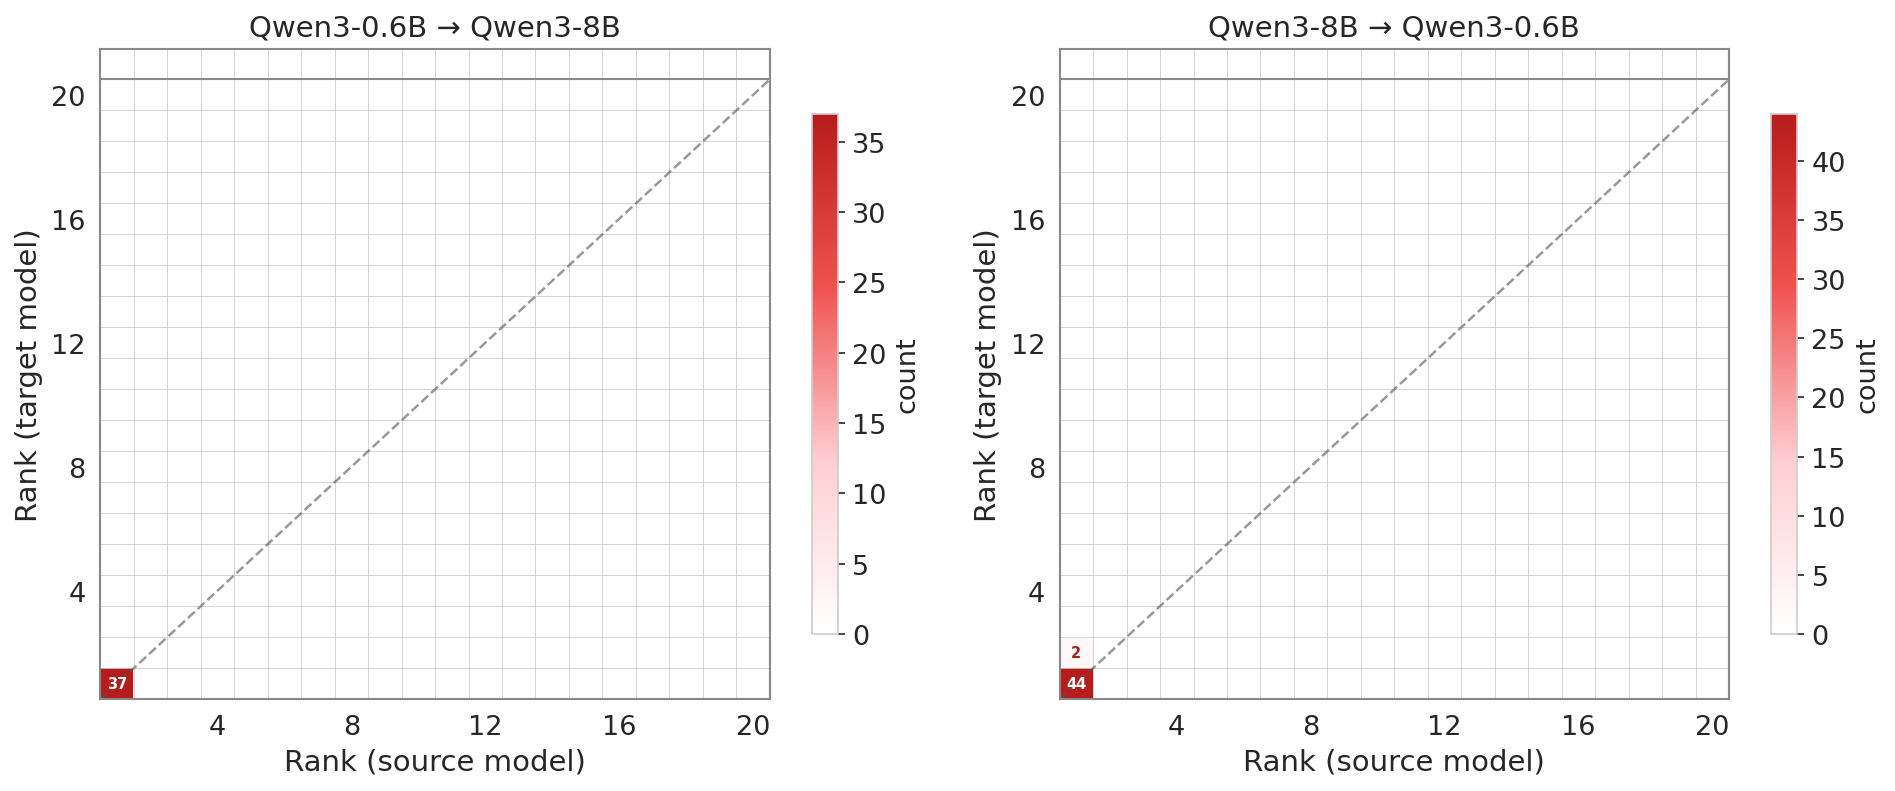

saved fig13_rank_UC_qwen3.png + .pdf


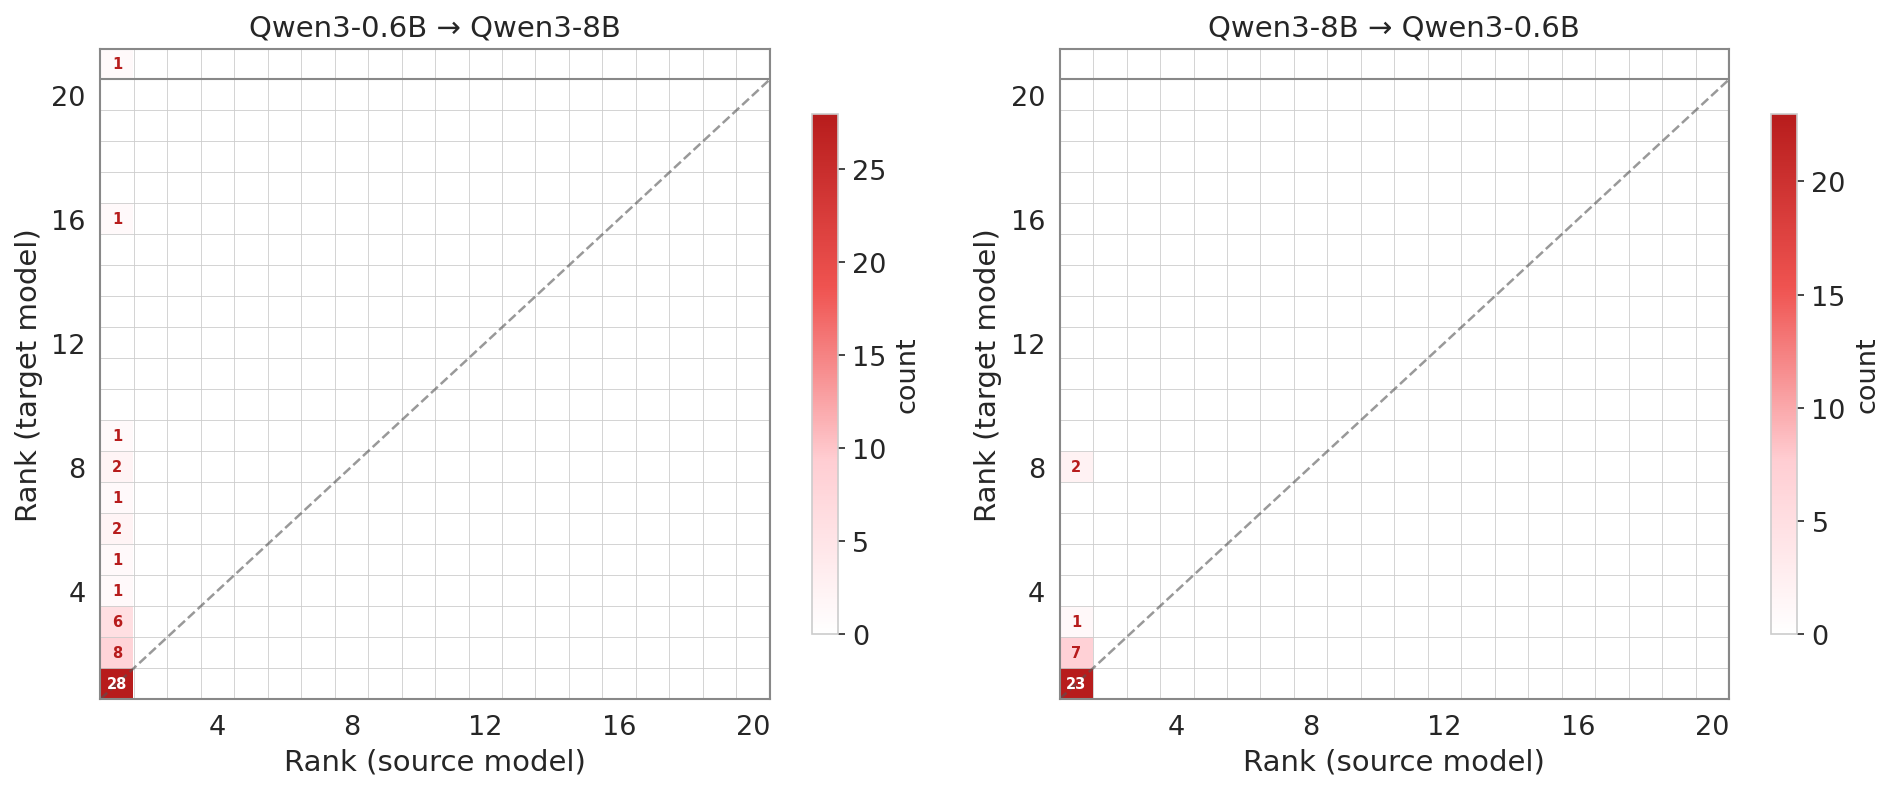

saved fig14_rank_SC_qwen3.png + .pdf


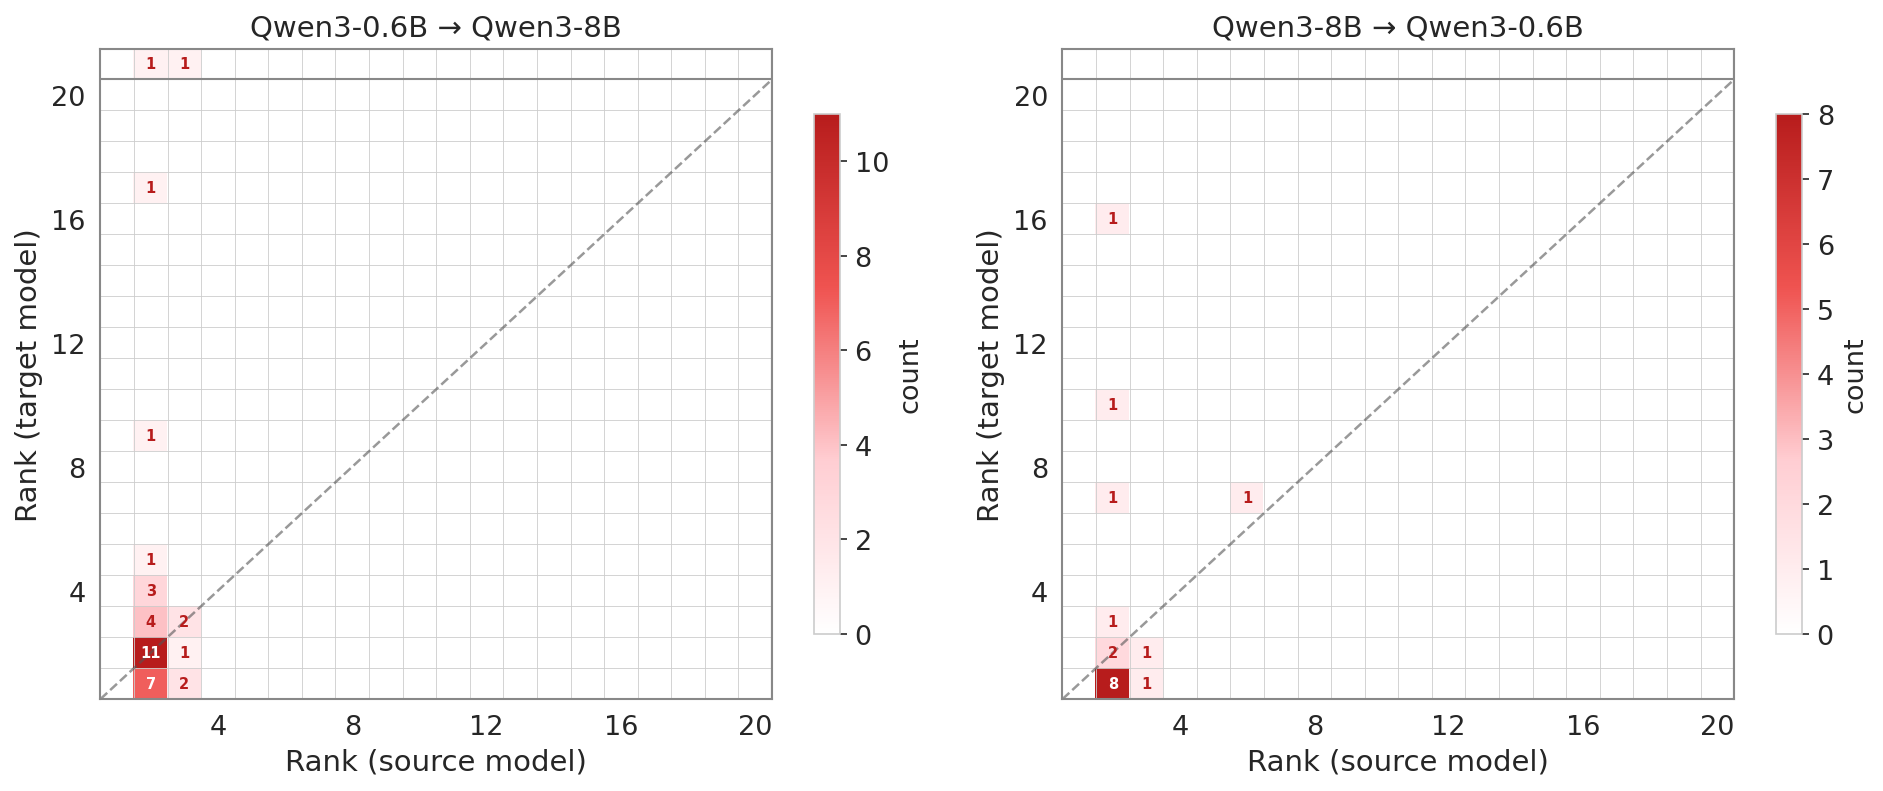

saved fig12_rank_DC_llama.png + .pdf


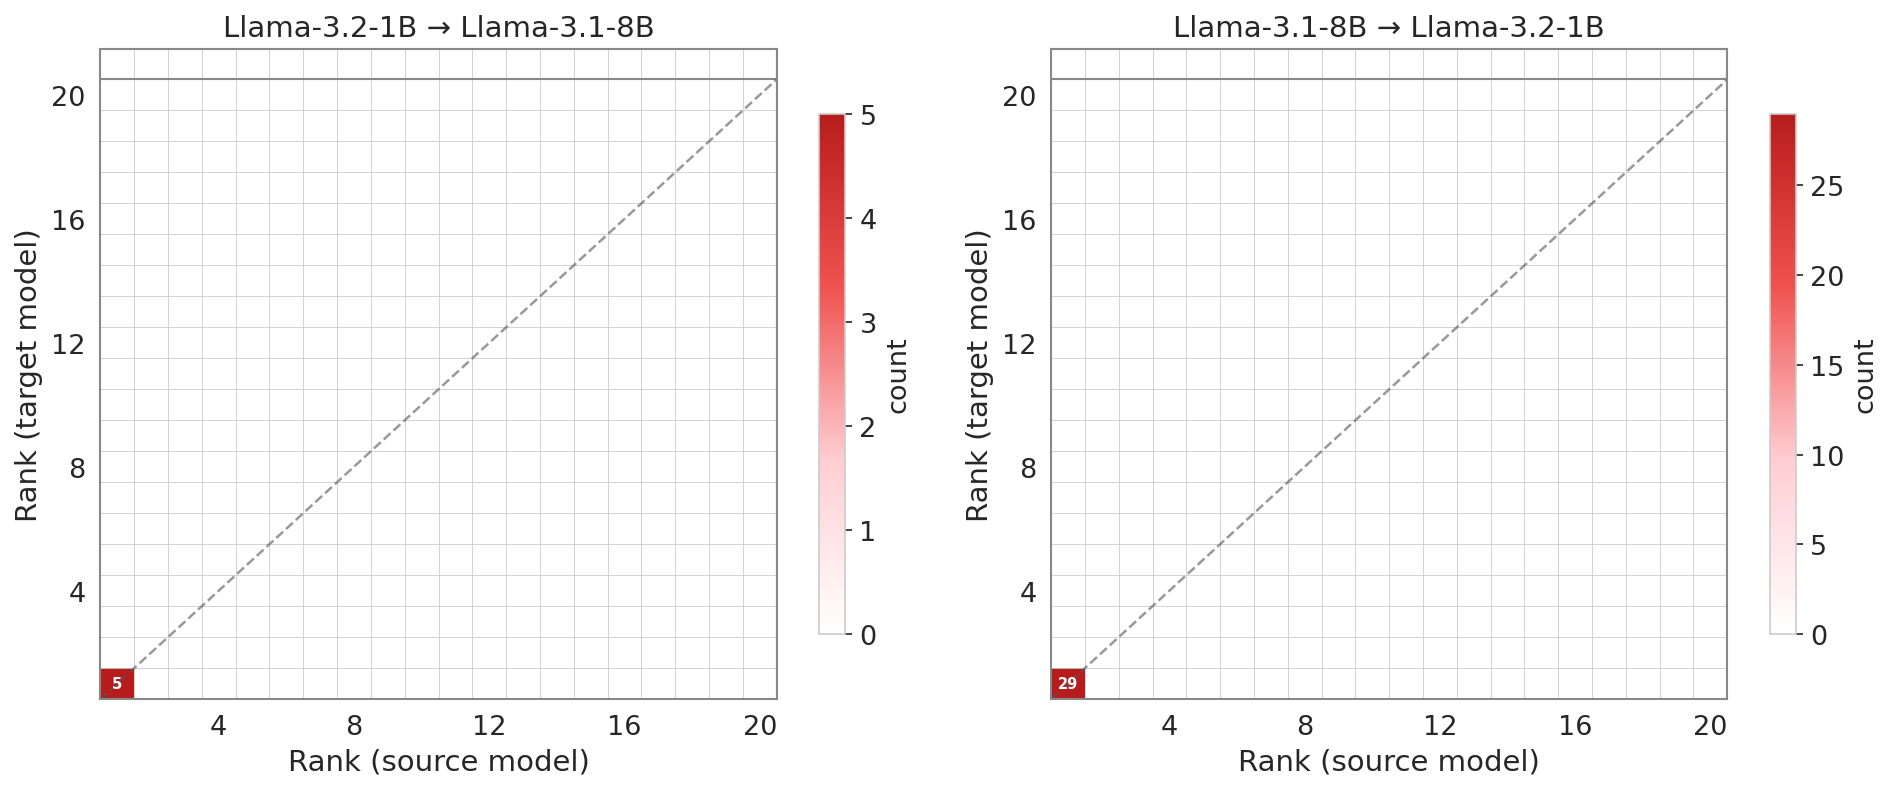

saved fig13_rank_UC_llama.png + .pdf


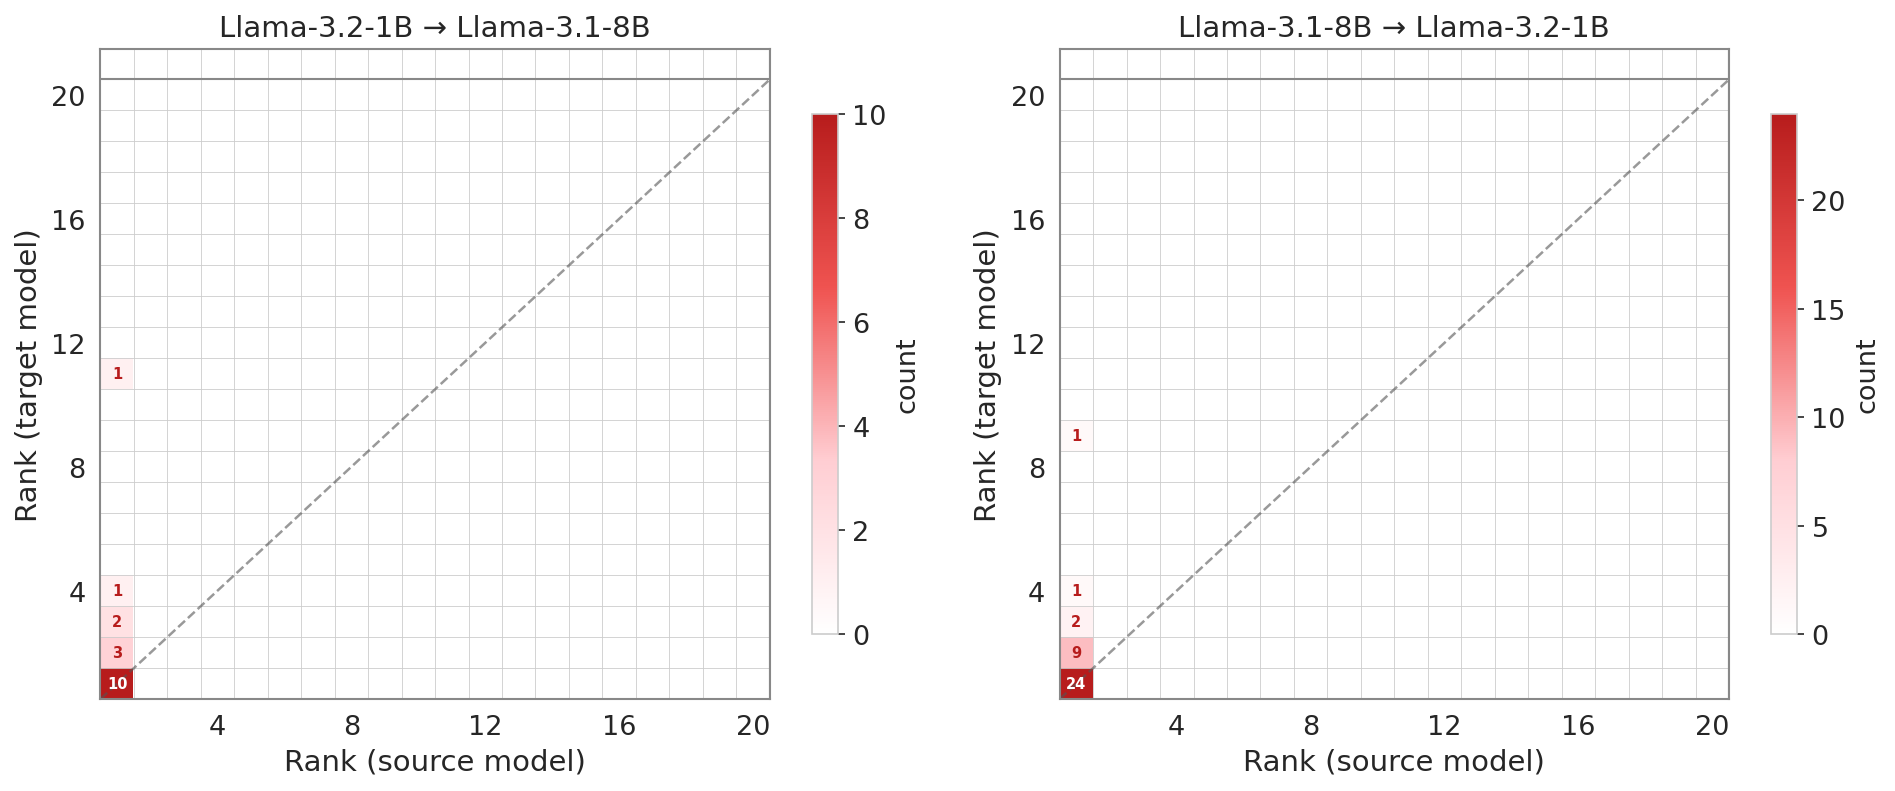

saved fig14_rank_SC_llama.png + .pdf


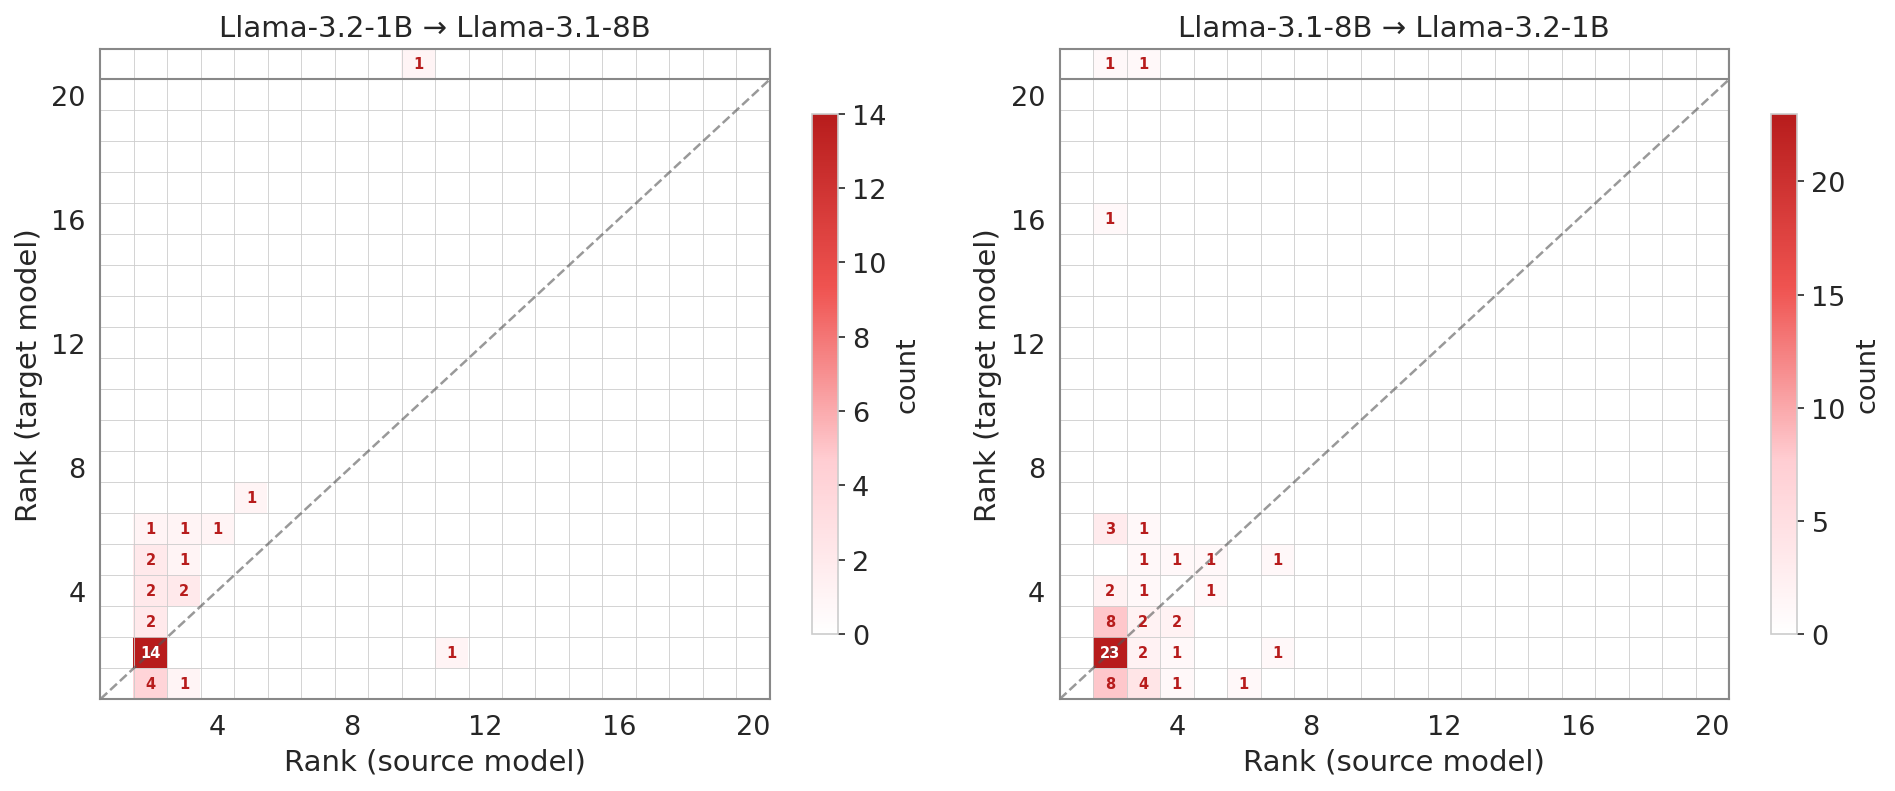

In [15]:
# ─── Figures 12, 13, 14 family: exp2_3 rank-shift heatmaps (Qwen3 and Llama) ───
import pandas as pd
FS = {"label": 14, "title": 14, "annot": 13, "cbar": 13, "cell": 7}
TAXONOMY_ORDER = ["DF", "AG", "SS"]
TAXONOMY_LABELS = {"DF": "Deterministic cliff",
                   "AG": "Uncertain cliff",
                   "SS": "Sampled-off cliff"}
TAX_FIG_SUFFIX = {"DF": "DC", "AG": "UC", "SS": "SC"}

cmap_red = LinearSegmentedColormap.from_list(
    "cliff_red", ["#FFFFFF", "#FFCDD2", "#EF5350", "#B71C1C"])

TICK_POSITIONS = [4, 8, 12, 16, 20]
GRID_COLOR = "#cccccc"
GRID_LW = 0.4
BORDER_COLOR = "#888888"
BORDER_LW = 1.0

EXP2_3_FAMILIES = [
    ("qwen3", DATA / "11_14_exp2_3_qwen3_extra_plots",
     {"smalltobig": "Qwen3-0.6B → Qwen3-8B", "bigtosmall": "Qwen3-8B → Qwen3-0.6B"}),
    ("llama", DATA / "11_14_exp2_3_llama_extra_plots",
     {"smalltobig": "Llama-3.2-1B → Llama-3.1-8B", "bigtosmall": "Llama-3.1-8B → Llama-3.2-1B"}),
]

def _load_filtered_tokens(base, direction):
    tok = pd.read_csv(base / f"{direction}_per_token.csv")
    keys = pd.read_csv(base / f"{direction}_selected_cliff_keys.csv")
    sel = {(str(r.path_id), int(r.cliff_position)): int(r.candidate_token_id)
           for r in keys.itertuples(index=False)}
    rows = []
    for r in tok.itertuples(index=False):
        rkey = (str(r.data_idx), int(r.cliff_position))
        if rkey not in sel or sel[rkey] != int(r.cliff_token_id):
            continue
        d = r._asdict()
        tax = d["taxonomy_type"]
        if tax in ("AG", "DF") and int(d["source_rank"]) != 1:
            d["source_rank"] = 1
        elif tax == "SS" and int(d["source_rank"]) == 1:
            d["source_rank"] = 2
        rows.append(d)
    return rows

def plot_rank_heatmaps(family_suffix, base, direction_labels):
    data = {
        "smalltobig": {"token": _load_filtered_tokens(base, "smalltobig")},
        "bigtosmall": {"token": _load_filtered_tokens(base, "bigtosmall")},
    }
    for tax in TAXONOMY_ORDER:
        apply_style()
        fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
        for di, direction in enumerate(["smalltobig", "bigtosmall"]):
            ax = axes[di]
            ax.grid(False)
            rows_filt = [r for r in data[direction]["token"] if r["taxonomy_type"] == tax]
            source_ranks = [r["source_rank"] for r in rows_filt]
            eval_ranks = [r["eval_rank"] for r in rows_filt]
            bins_x = np.arange(0.5, 21.5, 1); bins_y = np.arange(0.5, 22.5, 1)
            h, _, _ = np.histogram2d(source_ranks, eval_ranks, bins=[bins_x, bins_y])
            im = ax.imshow(h.T, origin="lower", aspect="auto",
                           extent=[0.5, 20.5, 0.5, 21.5],
                           cmap=cmap_red, interpolation="nearest")
            cb = plt.colorbar(im, ax=ax, shrink=0.8)
            cb.ax.tick_params(labelsize=FS["cbar"])
            cb.set_label("count", fontsize=FS["cbar"])
            hmax = h.max() if h.size else 0
            for xi in range(20):
                for yi in range(21):
                    val = int(h[xi, yi])
                    if val > 0:
                        text_color = "white" if hmax and val > hmax * 0.5 else "#B71C1C"
                        ax.text(xi + 1, yi + 1, str(val), ha="center", va="center",
                                fontsize=FS["cell"], color=text_color, fontweight="bold")
            ax.plot([0.5, 20.5], [0.5, 20.5], color="#555555", linestyle="--",
                    linewidth=1.2, alpha=0.6)
            ax.set_xticks(TICK_POSITIONS)
            ax.set_xticklabels([str(t) for t in TICK_POSITIONS], fontsize=FS["annot"])
            ax.set_yticks(TICK_POSITIONS)
            ax.set_yticklabels([str(t) for t in TICK_POSITIONS], fontsize=FS["annot"])
            for g in range(1, 20):
                ax.axvline(g + 0.5, color=GRID_COLOR, linewidth=GRID_LW, zorder=0)
                ax.axhline(g + 0.5, color=GRID_COLOR, linewidth=GRID_LW, zorder=0)
            ax.axvline(20.5, color=BORDER_COLOR, linewidth=BORDER_LW, zorder=1)
            ax.axhline(20.5, color=BORDER_COLOR, linewidth=BORDER_LW, zorder=1)
            for spine in ax.spines.values():
                spine.set_edgecolor(BORDER_COLOR)
                spine.set_linewidth(BORDER_LW)
            ax.set_xlabel("Rank (source model)", fontsize=FS["label"])
            ax.set_ylabel("Rank (target model)", fontsize=FS["label"])
            ax.set_title(direction_labels[direction], fontsize=FS["title"])
        fig.tight_layout()
        fig_idx = {"DF": 12, "AG": 13, "SS": 14}[tax]
        save_fig(fig, f"fig{fig_idx}_rank_{TAX_FIG_SUFFIX[tax]}_{family_suffix}")
        plt.show()
        plt.close(fig)

for family_suffix, base, direction_labels in EXP2_3_FAMILIES:
    plot_rank_heatmaps(family_suffix, base, direction_labels)


saved fig15_entropy_density.png + .pdf


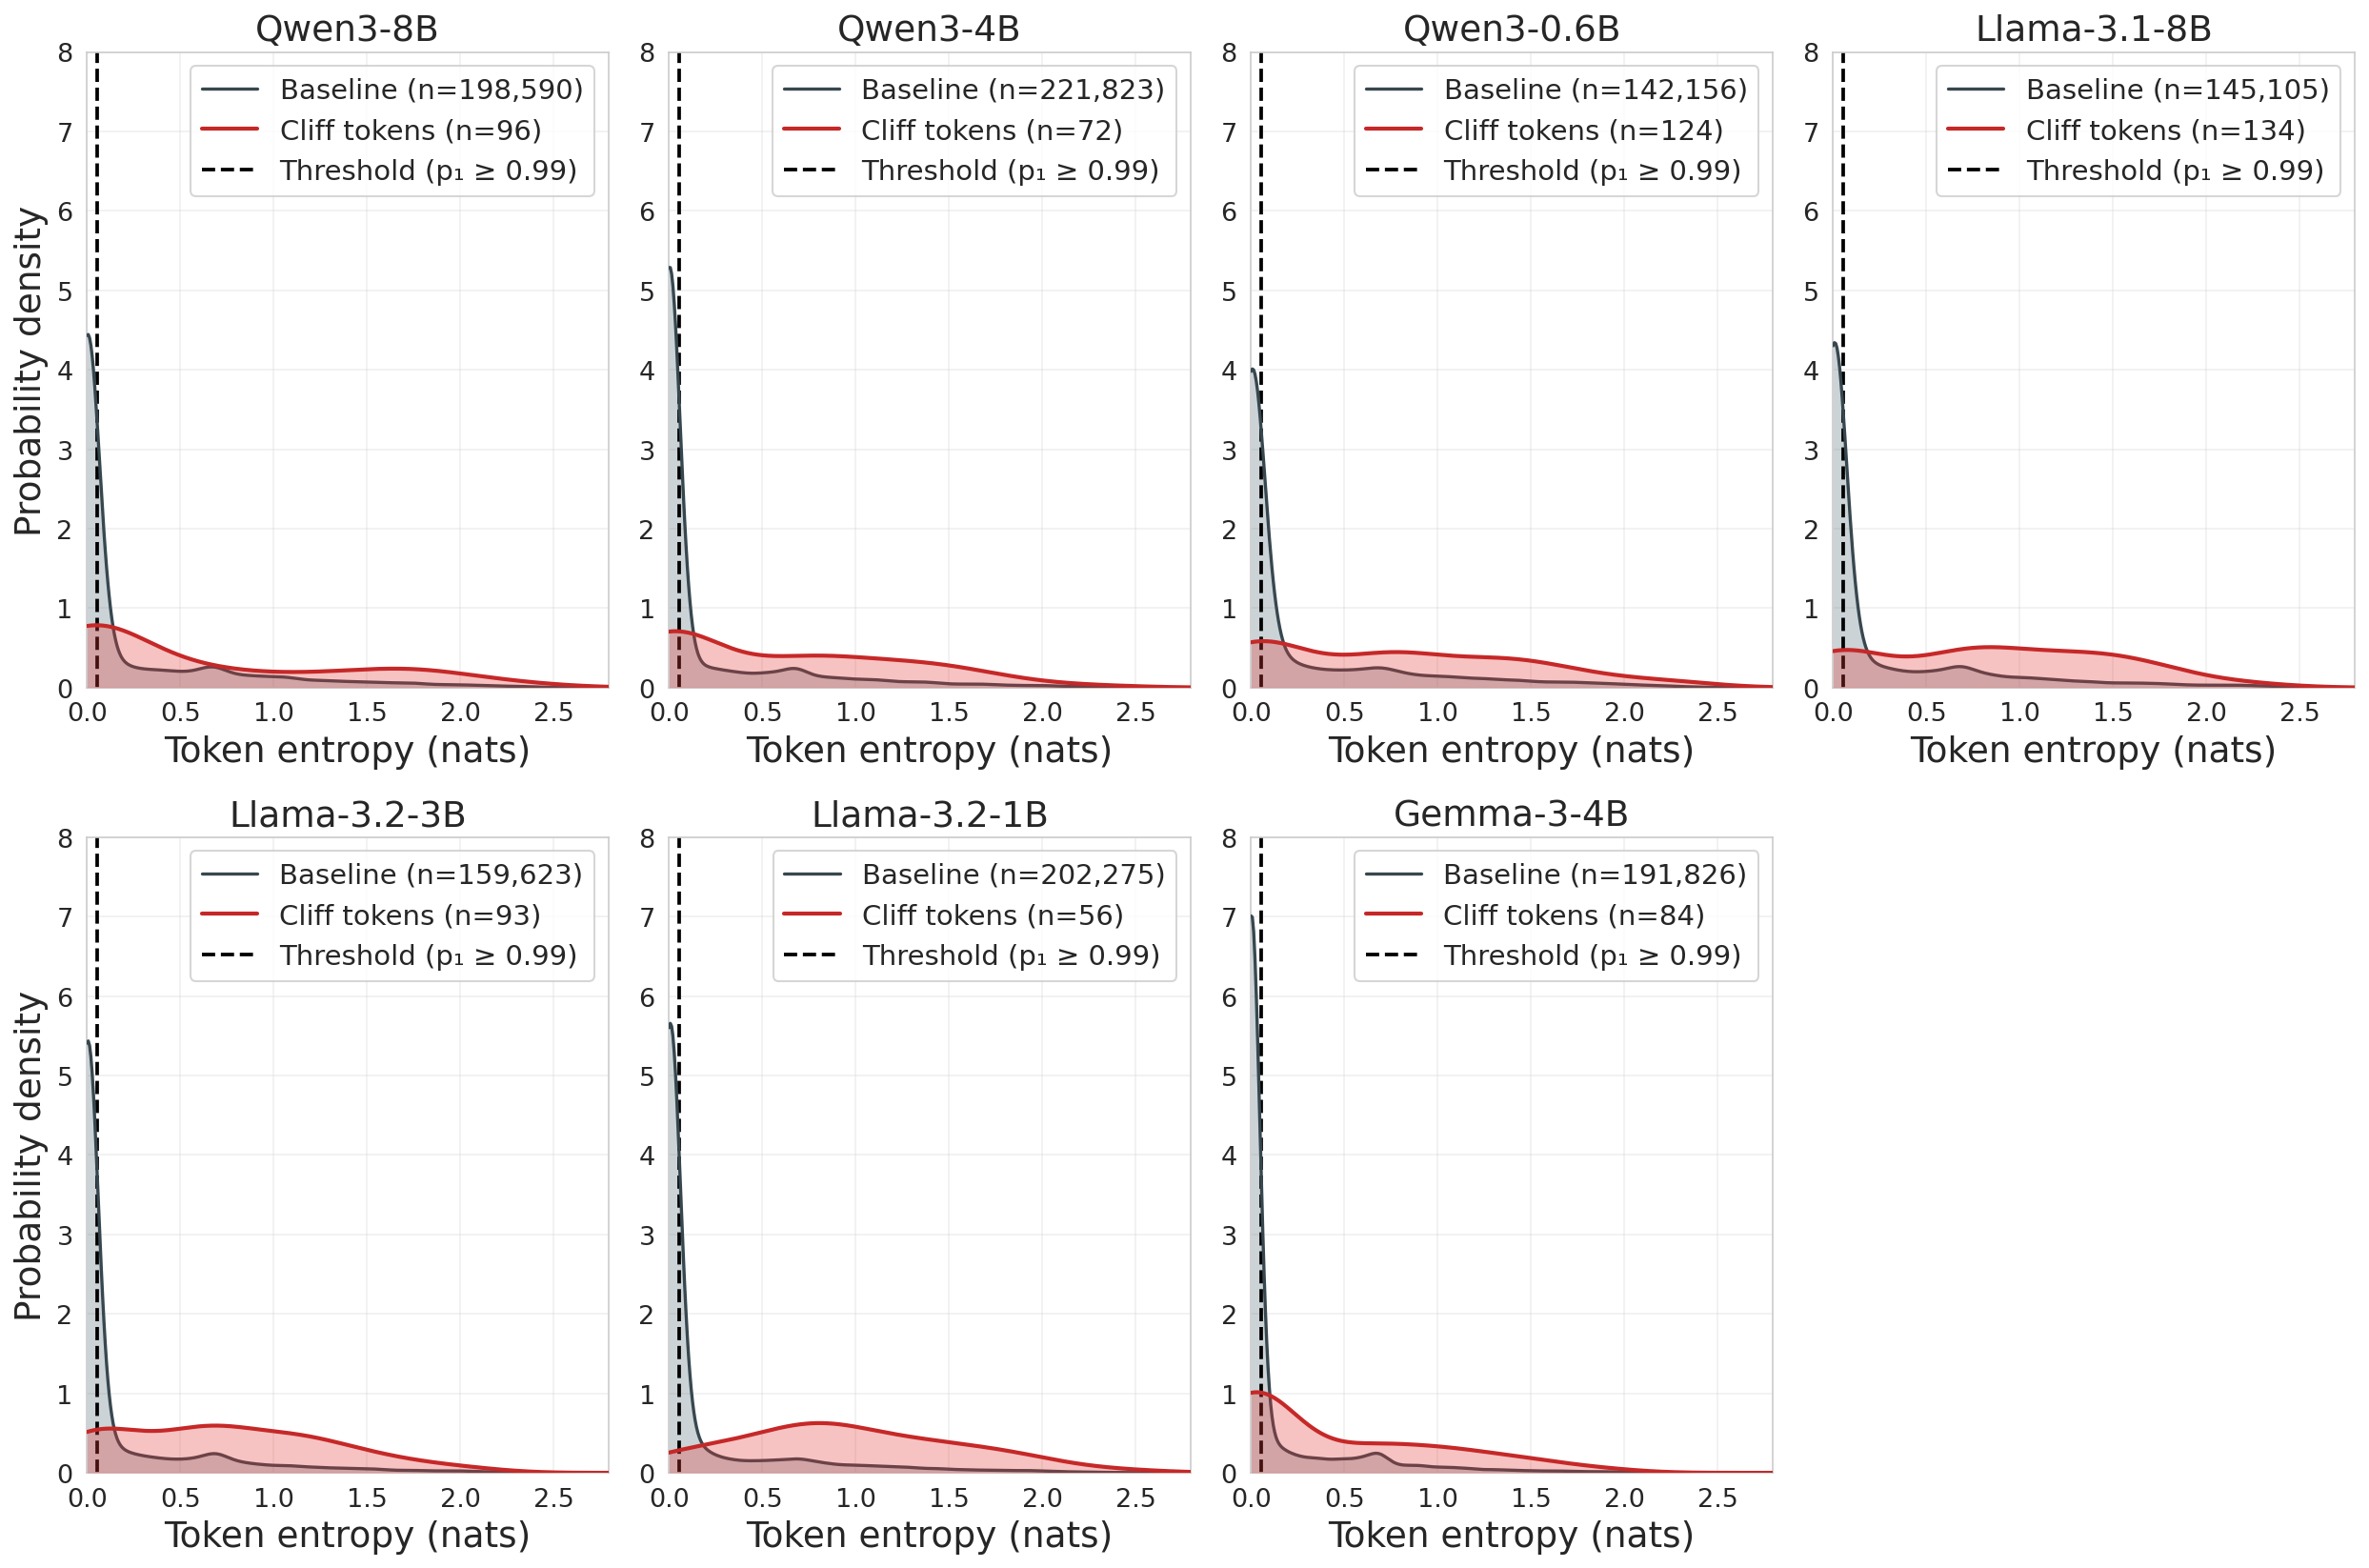

In [16]:
# ─── Figure 15: entropy density combined linear (7-panel KDE; 4+3 layout) ───
# Adapted from src/analysis/exp2_1_aggregator.py:make_entropy_density_combined
# + _draw_boundary_lines. Constants from src/analysis/entropy.py:
FS = {"title": 18, "label": 18, "legend": 14}
GREEDY_99_BOUND_NATS = float(-0.99*math.log(0.99) - 0.01*math.log(0.01))  # ≈ 0.0560

arr = np.load(DATA / "15_entropy_density/entropy_arrays.npz")
MODELS = [
    "Qwen3-8B", "Qwen3-4B", "Qwen3-0.6B",
    "Llama-3.1-8B-Instruct", "Llama-3.2-3B-Instruct", "Llama-3.2-1B-Instruct",
    "gemma-3-4b-it",
]
present = [m for m in MODELS if f"cliff_{m}" in arr.files]

x_max = 0.0
for m in present:
    if arr[f"cliff_{m}"].size:
        x_max = max(x_max, float(arr[f"cliff_{m}"].max()))
    if arr[f"base_{m}"].size:
        x_max = max(x_max, float(arr[f"base_{m}"].max()))
x_max = max(x_max * 1.05, 1.0)
grid_x = np.linspace(0.0, x_max, 400)

def kde_curve(values):
    a = np.asarray(values, dtype=float)
    if a.size < 2 or np.std(a) < 1e-8:
        return None
    return gaussian_kde(a, bw_method="scott")(grid_x)

apply_style()
n = len(present)
n_cols = 4
n_rows = int(math.ceil(n / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 5.6 * n_rows), sharey=False, squeeze=False)
axes_flat = axes.ravel()
for idx, (ax, m) in enumerate(zip(axes_flat, present)):
    cliff_v = arr[f"cliff_{m}"]
    base_v = arr[f"base_{m}"]
    n_base_full = int(arr[f"n_base_full_{m}"][0])
    by = kde_curve(base_v); cy = kde_curve(cliff_v)
    if by is not None:
        ax.fill_between(grid_x, by, color="#546E7A", alpha=0.30, linewidth=0, zorder=2)
        ax.plot(grid_x, by, color="#37474F", linewidth=1.6,
                label=f"Baseline (n={n_base_full:,})", zorder=3)
    if cy is not None:
        ax.fill_between(grid_x, cy, color="#E53935", alpha=0.30, linewidth=0, zorder=4)
        ax.plot(grid_x, cy, color="#C62828", linewidth=2.0,
                label=f"Cliff tokens (n={cliff_v.size})", zorder=5)
    # E*99 boundary line only (E*95 reference line removed per request)
    ax.axvline(GREEDY_99_BOUND_NATS, color="black", linestyle="--", linewidth=1.8,
               label=f"Threshold (p₁ ≥ 0.99)")
    ax.set_xlim(0, x_max); ax.set_ylim(0, 8)
    ax.set_ylabel("Probability density" if idx % n_cols == 0 else "", fontsize=FS["label"])
    ax.set_xlabel("Token entropy (nats)", fontsize=FS["label"])
    ax.set_title(display_model(m), fontsize=FS["title"])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=FS["legend"])
for ax in axes_flat[n:]:
    ax.axis("off")
fig.tight_layout()
save_fig(fig, "fig15_entropy_density")
plt.show()
plt.close(fig)


saved fig16_passk_incorrect.png + .pdf


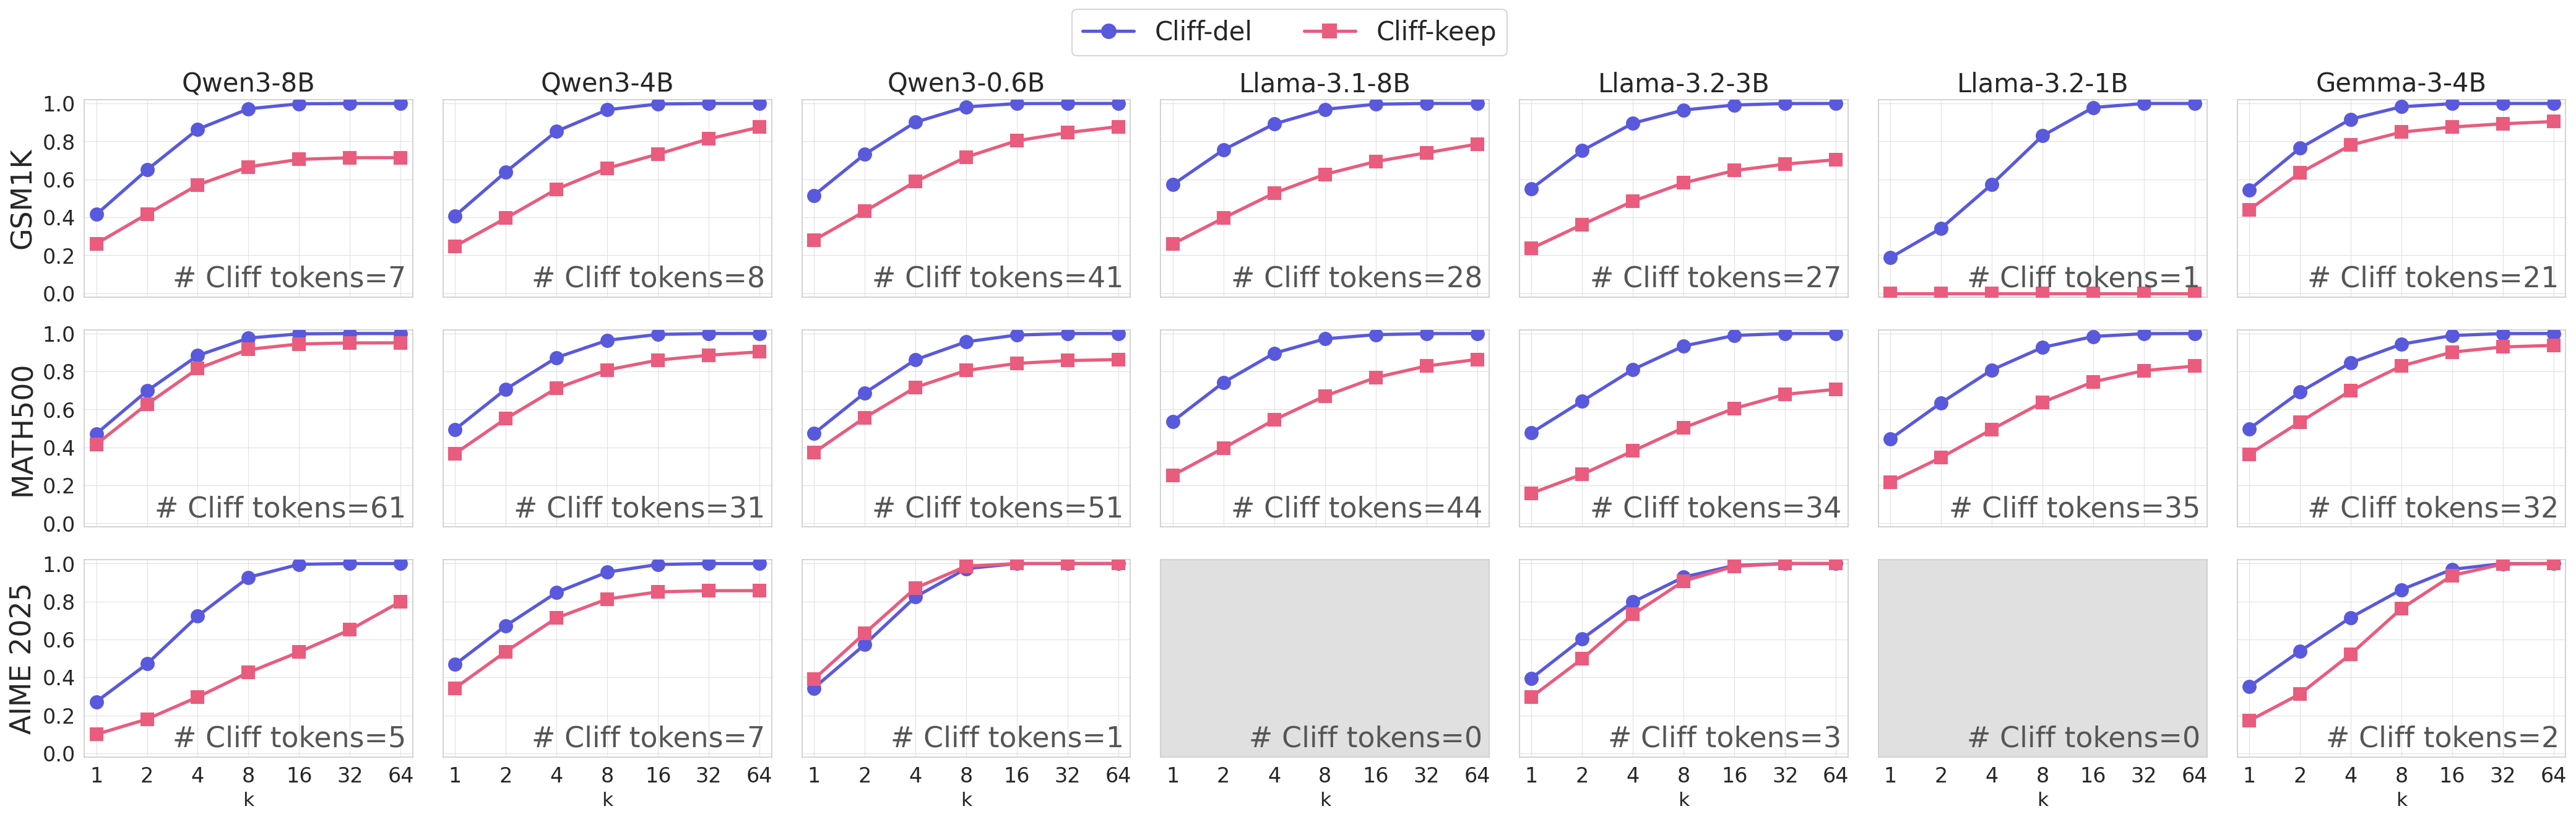

In [17]:
# ─── Figure 16: pass@k grid (failure paths only, transposed) ───
# Reproduces the failure-only pass@k grid from figure/data
# rows = datasets, cols = models; only the two failure-path lines are drawn.
import pandas as pd
df = pd.read_csv(DATA / "16_pass_at_k_failure_only/pass_at_k_failure_only.csv")

MODEL_DISPLAY_ORDER = ["Qwen3-8B", "Qwen3-4B", "Qwen3-0.6B",
                       "Llama-3.1-8B-Instruct", "Llama-3.2-3B-Instruct",
                       "Llama-3.2-1B-Instruct", "gemma-3-4b-it"]
DATASET_DISPLAY_ORDER = ["gsm1k", "math500", "aime25"]
DATASET_LABEL = {"gsm1k": "GSM1K", "math500": "MATH500", "aime25": "AIME 2025"}
FS = {"tick": 16, "title": 20, "label": 22, "annot": 22, "legend": 20}
EXP1_LINES = {
    "del":  {"color": "#5959DD", "marker": "o", "label": "Cliff-del"},
    "keep": {"color": "#E95C7E", "marker": "s", "label": "Cliff-keep"},
}

K_TICKS = [1, 2, 4, 8, 16, 32, 64]
Y_TICKS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

apply_style()
all_datasets = [d for d in DATASET_DISPLAY_ORDER if d in df["dataset"].unique()]
all_models = [m for m in MODEL_DISPLAY_ORDER if m in df["model"].unique()]
n_rows, n_cols = len(all_datasets), len(all_models)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

def style_axes(ax):
    ax.set_xscale("log", base=2)
    ax.set_xticks(K_TICKS); ax.set_xticklabels([str(k) for k in K_TICKS], fontsize=FS["tick"])
    ax.set_yticks(Y_TICKS); ax.set_yticklabels([f"{y:.1f}" for y in Y_TICKS], fontsize=FS["tick"])
    ax.set_xlim(K_TICKS[0] * 0.85, K_TICKS[-1] * 1.18)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, which="major", color="#E0E0E0", linewidth=0.5, alpha=1, zorder=0)
    ax.set_axisbelow(True)

for i, ds in enumerate(all_datasets):
    for j, model in enumerate(all_models):
        ax = axes[i][j]
        style_axes(ax)
        cell = df[(df["model"] == model) & (df["dataset"] == ds)].sort_values("k")
        if cell.empty:
            ax.set_facecolor("#E0E0E0")
            ax.text(0.98, 0.02, "# Cliff tokens=0",
                    transform=ax.transAxes, fontsize=FS["annot"], ha="right", va="bottom",
                    color="#555555")
        else:
            n_fail = int(cell["n_failure"].iloc[0])
            n_tot  = int(cell["n_total_cliffs"].iloc[0])
            for src_key in ("del", "keep"):
                style = EXP1_LINES[src_key]
                col = f"cliff_{src_key}_pass_at_k"
                ax.plot(cell["k"], cell[col],
                        color=style["color"], linestyle="-", linewidth=2.5,
                        marker=style["marker"], markersize=10, zorder=3)
            ax.text(0.98, 0.02, f"# Cliff tokens={n_fail}",
                    transform=ax.transAxes, fontsize=FS["annot"], ha="right", va="bottom",
                    color="#555555")
        if i == 0: ax.set_title(display_model(model), fontsize=FS["title"])
        if j == 0: ax.set_ylabel(DATASET_LABEL.get(ds, ds), fontsize=FS["label"])
        if i == n_rows - 1: ax.set_xlabel("k")
        if i != n_rows - 1: ax.tick_params(labelbottom=False)
        if j != 0: ax.tick_params(labelleft=False)

handles = [Line2D([0], [0], color=s["color"], marker=s["marker"], linestyle="-",
                  linewidth=2.5, markersize=11, label=s["label"])
           for s in EXP1_LINES.values()]
fig.legend(handles=handles, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, 0.95), frameon=True, fontsize=FS["legend"])
fig.tight_layout(rect=[0, 0.04, 1, 0.97])
save_fig(fig, "fig16_passk_incorrect")
plt.show()
plt.close(fig)

saved fig17_passk_correct.png + .pdf


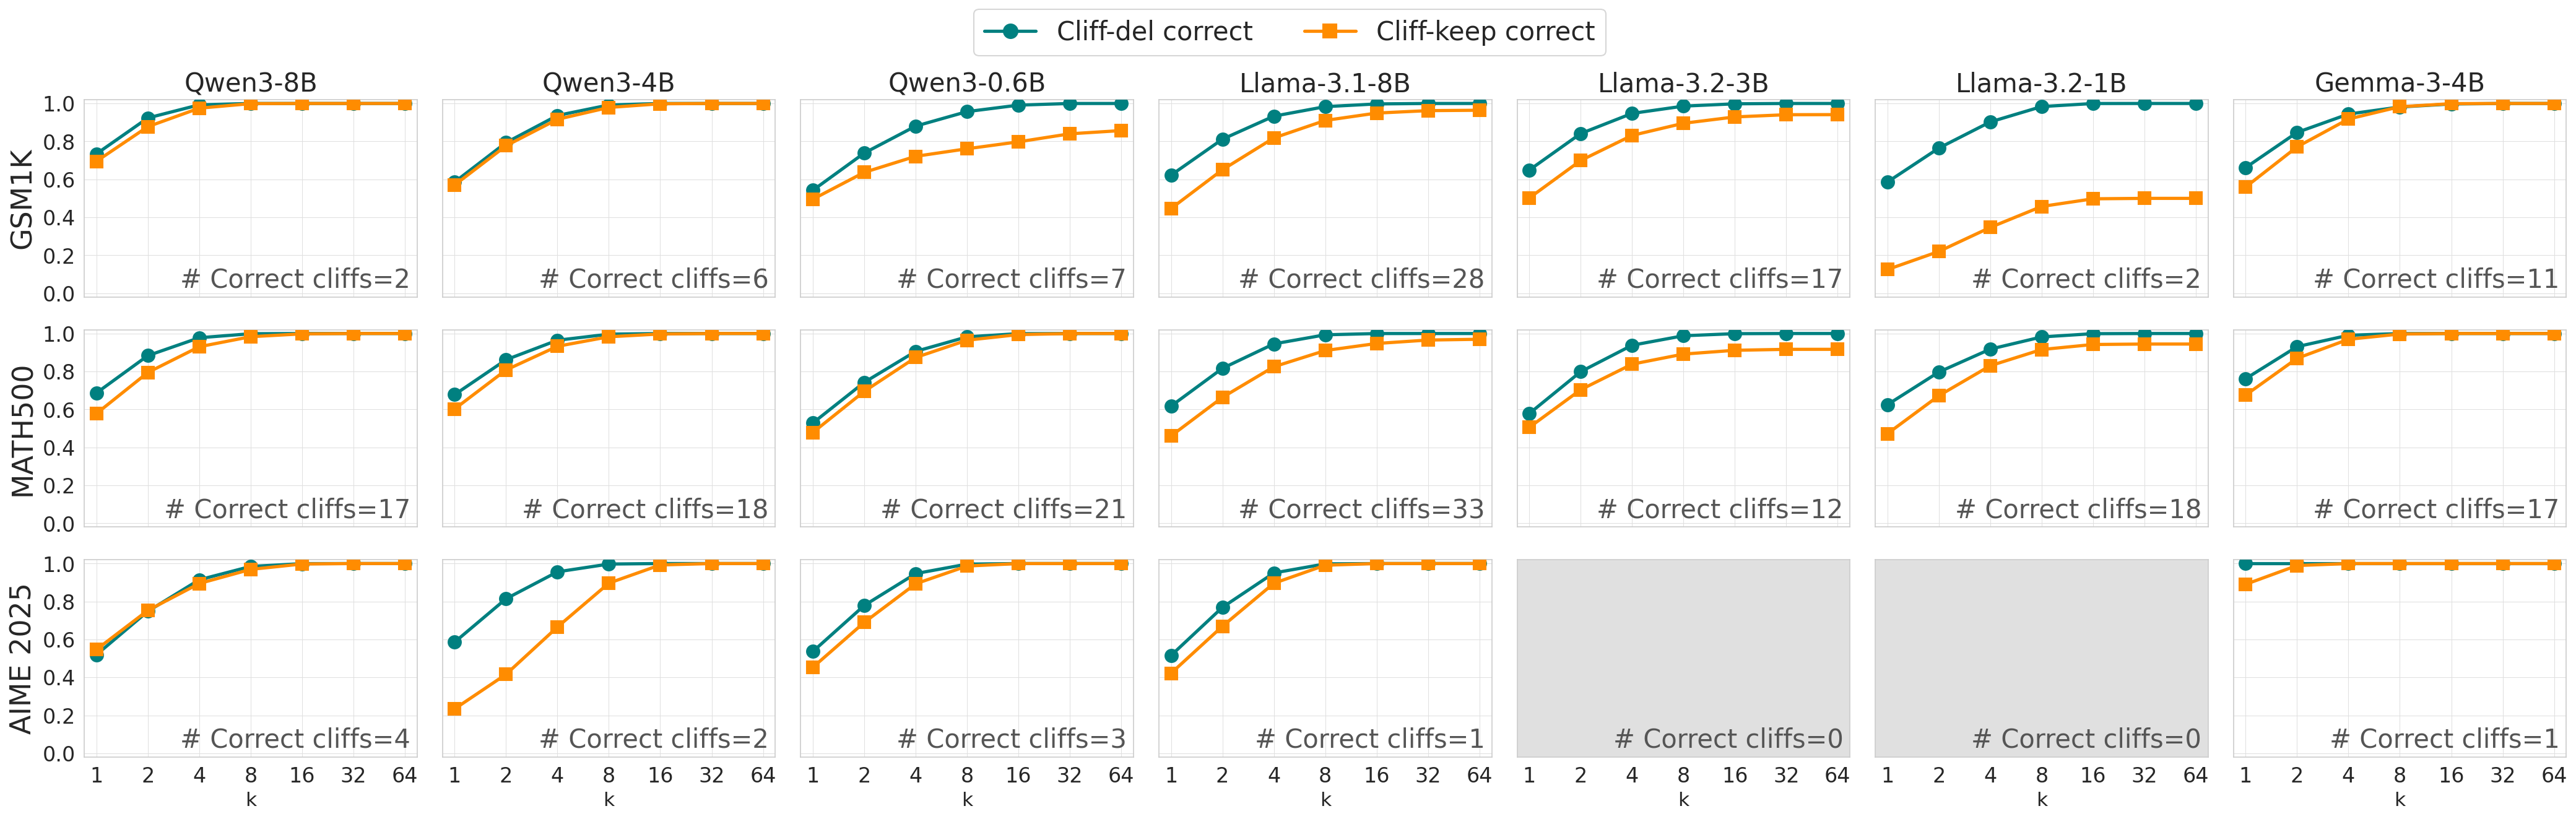

In [18]:
# ─── Figure 17: pass@k grid (correct paths only, transposed) ───
# Old Figure 04 correct-path view, restyled like Figure 16.
import pandas as pd
df = pd.read_csv(DATA / "17_pass_at_k_all_paths/pass_at_k.csv")

MODEL_DISPLAY_ORDER = ["Qwen3-8B", "Qwen3-4B", "Qwen3-0.6B",
                       "Llama-3.1-8B-Instruct", "Llama-3.2-3B-Instruct",
                       "Llama-3.2-1B-Instruct", "gemma-3-4b-it"]
DATASET_DISPLAY_ORDER = ["gsm1k", "math500", "aime25"]
DATASET_LABEL = {"gsm1k": "GSM1K", "math500": "MATH500", "aime25": "AIME 2025"}
FS = {"tick": 16, "title": 20, "label": 22, "annot": 20, "legend": 20}
CORRECT_PATH_LINES = {
    "del_success":  {"color": "#008080", "marker": "o", "linestyle": "-", "label": "Cliff-del correct"},
    "keep_success": {"color": "#ff8c00", "marker": "s", "linestyle": "-", "label": "Cliff-keep correct"},
}

K_TICKS = [1, 2, 4, 8, 16, 32, 64]
Y_TICKS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

apply_style()
all_datasets = [d for d in DATASET_DISPLAY_ORDER if d in df["dataset"].unique()]
all_models = [m for m in MODEL_DISPLAY_ORDER if m in df["model"].unique()]
n_rows, n_cols = len(all_datasets), len(all_models)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

def style_axes(ax):
    ax.set_xscale("log", base=2)
    ax.set_xticks(K_TICKS); ax.set_xticklabels([str(k) for k in K_TICKS], fontsize=FS["tick"])
    ax.set_yticks(Y_TICKS); ax.set_yticklabels([f"{y:.1f}" for y in Y_TICKS], fontsize=FS["tick"])
    ax.set_xlim(K_TICKS[0] * 0.85, K_TICKS[-1] * 1.18)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, which="major", color="#E0E0E0", linewidth=0.5, alpha=1, zorder=0)
    ax.set_axisbelow(True)

for i, ds in enumerate(all_datasets):
    for j, model in enumerate(all_models):
        ax = axes[i][j]
        style_axes(ax)
        cell = df[(df["model"] == model) & (df["dataset"] == ds)].sort_values("k")
        n_success = int(cell["n_success"].iloc[0]) if not cell.empty else 0
        cell = cell[cell["line_type"].isin(CORRECT_PATH_LINES.keys())]
        if cell.empty or n_success == 0:
            ax.set_facecolor("#E0E0E0")
            ax.text(0.98, 0.02, "# Correct cliffs=0",
                    transform=ax.transAxes, fontsize=FS["annot"], ha="right", va="bottom",
                    color="#555555")
        else:
            for src_key, style in CORRECT_PATH_LINES.items():
                sub = cell[cell["line_type"] == src_key]
                if sub.empty:
                    continue
                ax.plot(sub["k"], sub["pass_at_k"],
                        color=style["color"], linestyle=style["linestyle"], linewidth=2.5,
                        marker=style["marker"], markersize=10, zorder=3)
            ax.text(0.98, 0.02, f"# Correct cliffs={n_success}",
                    transform=ax.transAxes, fontsize=FS["annot"], ha="right", va="bottom",
                    color="#555555")
        if i == 0: ax.set_title(display_model(model), fontsize=FS["title"])
        if j == 0: ax.set_ylabel(DATASET_LABEL.get(ds, ds), fontsize=FS["label"])
        if i == n_rows - 1: ax.set_xlabel("k")
        if i != n_rows - 1: ax.tick_params(labelbottom=False)
        if j != 0: ax.tick_params(labelleft=False)

handles = [Line2D([0], [0], color=s["color"], marker=s["marker"], linestyle=s["linestyle"],
                  linewidth=2.5, markersize=11, label=s["label"])
           for s in CORRECT_PATH_LINES.values()]
fig.legend(handles=handles, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, 0.95), frameon=True, fontsize=FS["legend"])
fig.tight_layout(rect=[0, 0.04, 1, 0.97])
save_fig(fig, "fig17_passk_correct")
plt.show()
plt.close(fig)
